In [ ]:
# MÓDULO 1: PREPARAÇÃO DE DADOS (ETL)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração visual para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Carregando o dataset Steam...")
# Lendo o arquivo
df_steam = pd.read_csv("/kaggle/input/datasets/fronkongames/steam-games-dataset/games.csv")

# Selecionando as colunas que serão usadas
colunas_alvo = [
    'AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
    'Price', 'DiscountDLC count', 'Supported languages',
    'Windows', 'Mac', 'Linux', 'Metacritic score',
    'Positive', 'Negative', 'Average playtime forever', 'Genres'
]
df_clean = df_steam[colunas_alvo].copy()


# FEATURE ENGINEERING (Criando novas métricas)

# 1. Engajamento: Total de Reviews e % de Aprovação
df_clean['Total Reviews'] = df_clean['Positive'] + df_clean['Negative']
# Evitando divisão por zero
df_clean['Approval (%)'] = (df_clean['Positive'] / df_clean['Total Reviews'].replace(0, 1)) * 100

# 2. Acessibilidade: Contagem de idiomas
df_clean['Num Languages'] = df_clean['Supported languages'].astype(str).apply(lambda x: len(x.split(',')))

# 3. Limpeza de nulos nas métricas críticas
df_clean['Metacritic score'] = df_clean['Metacritic score'].fillna(0)
df_clean['Price'] = df_clean['Price'].fillna(0.0)

print(f"São {len(df_clean)} jogos prontos para a análise exploratória.")
display(df_clean[['Name', 'Total Reviews', 'Approval (%)', 'Num Languages', 'Metacritic score']].head())

Carregando o dataset Steam...
São 122611 jogos prontos para a análise exploratória.


,Name,Total Reviews,Approval (%),Num Languages,Metacritic score
2539430,"Aug 1, 2023",0,0.000000,1,0
496350,"Jul 29, 2016",255,98.823529,1,0
1034400,"May 6, 2019",24,87.500000,4,0
3292190,"Oct 31, 2024",0,0.000000,1,0
3631080,"Apr 24, 2025",0,0.000000,1,0


Gerando análises do Módulo 2...


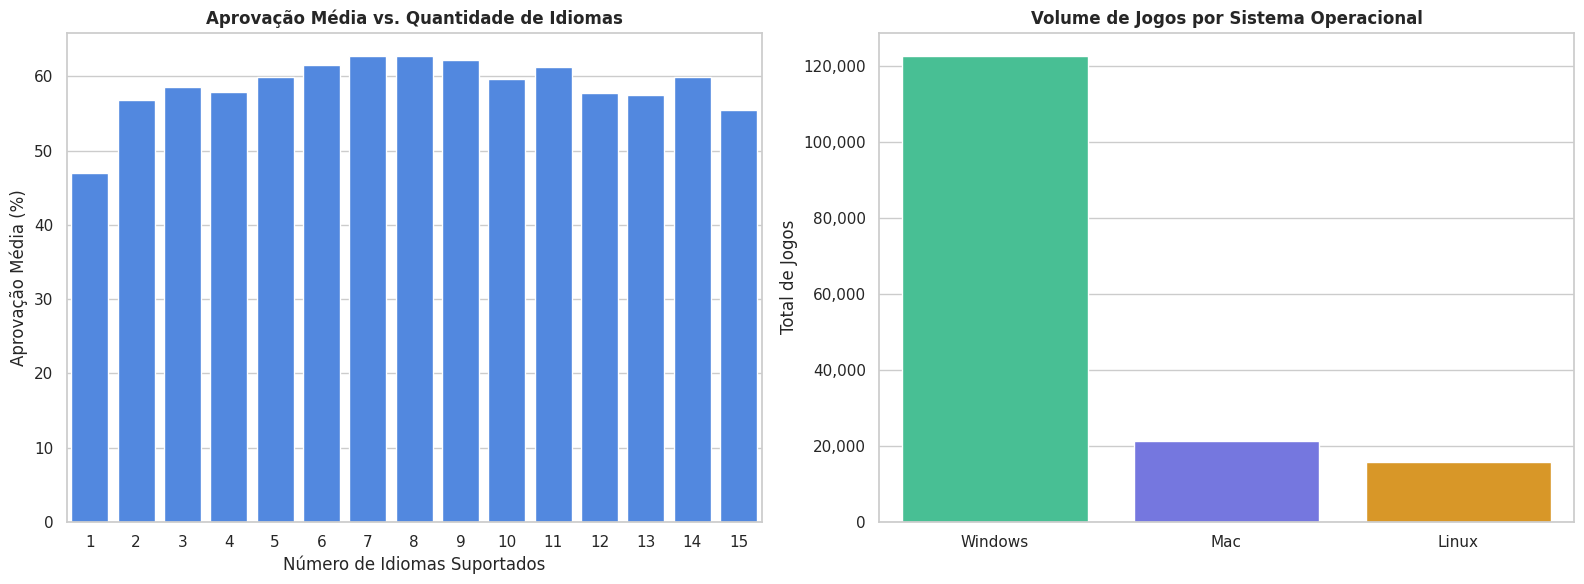

In [ ]:
# MÓDULO 2: IDIOMAS E PLATAFORMAS

print("Gerando análises do Módulo 2...")

# 1- IMPACTO DOS IDIOMAS
# Para o gráfico não ficar esmagado com outliers (jogos com 30 idiomas), 
# será focado nos jogos que suportam até 15 idiomas, que é a grande realidade do mercado.
df_idiomas = df_clean[df_clean['Num Languages'] <= 15].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Número de idiomas vs. Aprovação (%)
sns.barplot(data=df_idiomas, x='Num Languages', y='Approval (%)', ax=axes[0], color='#3b82f6', errorbar=None)
axes[0].set_title('Aprovação Média vs. Quantidade de Idiomas', fontweight='bold')
axes[0].set_xlabel('Número de Idiomas Suportados')
axes[0].set_ylabel('Aprovação Média (%)')

# 2- PLATAFORMAS
# Contando quantos jogos dão suporte a cada sistema operacional
plataformas = {
    'Windows': df_clean['Windows'].sum(),
    'Mac': df_clean['Mac'].sum(),
    'Linux': df_clean['Linux'].sum()
}

# Gráfico 2: Distribuição de Plataformas
sns.barplot(x=list(plataformas.keys()), y=list(plataformas.values()), ax=axes[1], hue=list(plataformas.keys()), palette=['#34d399', '#6366f1', '#f59e0b'], legend=False)
axes[1].set_title('Volume de Jogos por Sistema Operacional', fontweight='bold')
axes[1].set_ylabel('Total de Jogos')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ','))) # Formata os números com vírgula

plt.tight_layout()
plt.show()

Analisando o impacto comercial de cada idioma...


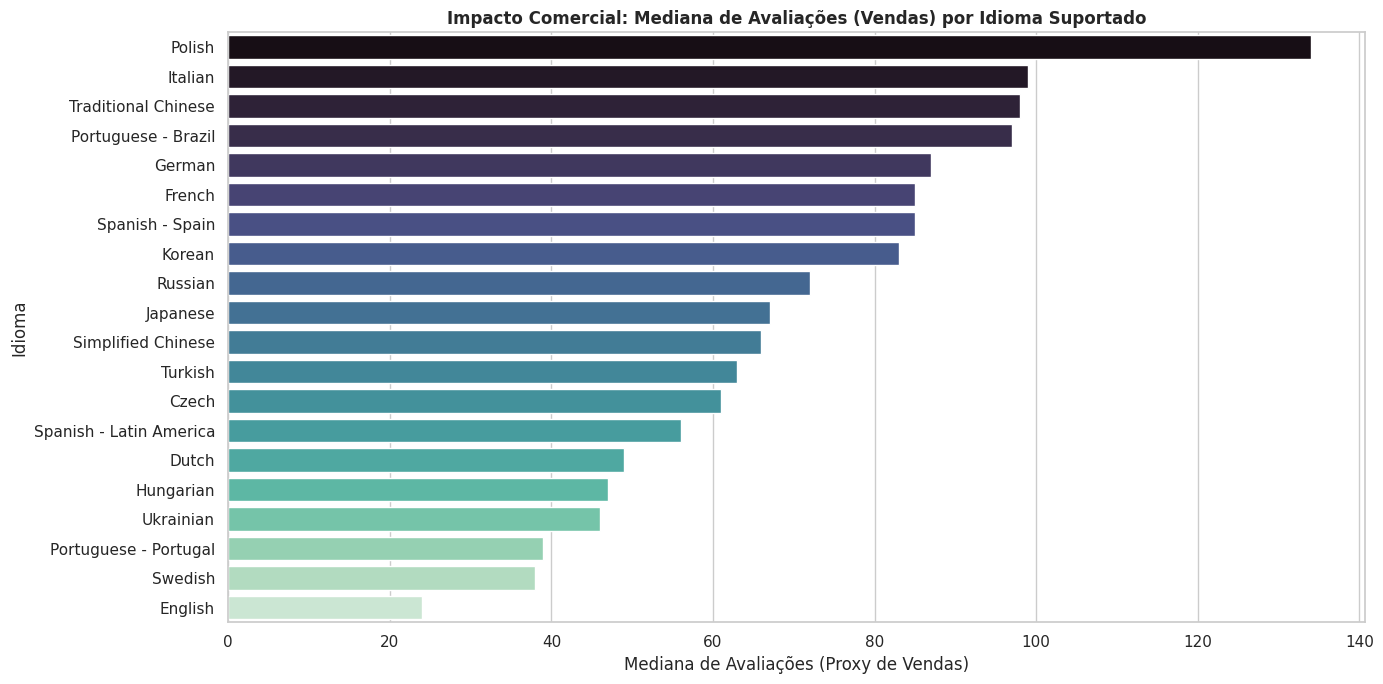

In [ ]:
# MÓDULO 3: O IMPACTO FINANCEIRO DOS IDIOMAS

print("Analisando o impacto comercial de cada idioma...")

# 1- Fazendo uma cópia segura e focando apenas em jogos que já "venderam" algo
df_langs = df_clean[df_clean['Total Reviews'] > 0].copy()

# 2- Limpando a coluna de idiomas
df_langs['Supported languages'] = df_langs['Supported languages'].astype(str)
df_langs['Supported languages'] = df_langs['Supported languages'].str.replace(r"[\[\]\']", "", regex=True)

# 3- Transformando o texto "English, French" em uma lista real do Python
df_langs['Lang List'] = df_langs['Supported languages'].apply(
    lambda x: [lang.strip() for lang in x.split(',') if lang.strip()]
)

# 4- Duplica a linha do jogo para cada idioma que ele possui
df_exploded = df_langs.explode('Lang List')

# 5- Filtrando os 20 idiomas mais comuns para o gráfico não ficar bagunçado
top_20_langs = df_exploded['Lang List'].value_counts().head(20).index
df_filtered_langs = df_exploded[df_exploded['Lang List'].isin(top_20_langs)]

# 6- Agrupando por Idioma e calculando a Mediana de Vendas (Reviews)
# Usa-se a Mediana para não deixar os jogos SUPER vendidos, como GTA V, distorcerem
impacto_idiomas = df_filtered_langs.groupby('Lang List')['Total Reviews'].median().sort_values(ascending=False).reset_index()

# 7- Plotando o resultado
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=impacto_idiomas, x='Total Reviews', y='Lang List', hue='Lang List', palette='mako', legend=False, ax=ax)

ax.set_title('Impacto Comercial: Mediana de Avaliações (Vendas) por Idioma Suportado', fontweight='bold')
ax.set_xlabel('Mediana de Avaliações (Proxy de Vendas)')
ax.set_ylabel('Idioma')

plt.tight_layout()
plt.show()

Gerando análises do Módulo 4...


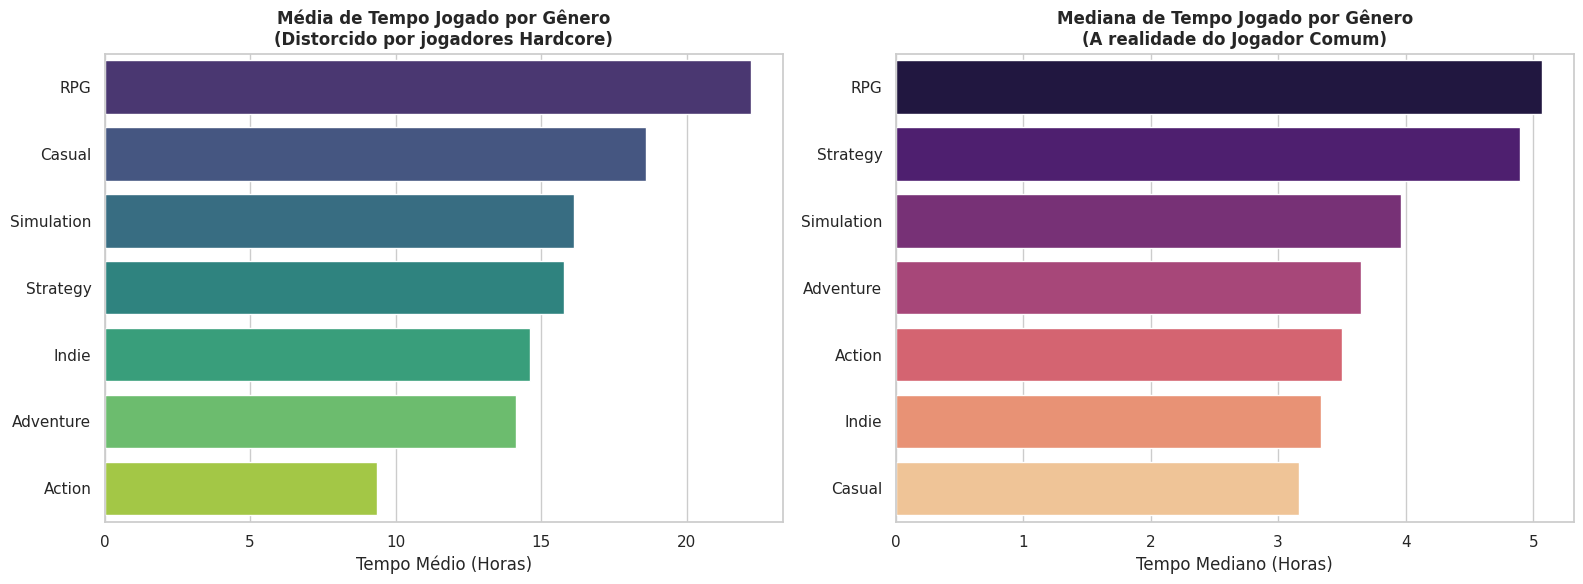

In [ ]:
# MÓDULO 4: RETENÇÃO (MÉDIA VS MEDIANA)

print("Gerando análises do Módulo 4...")

# Removendo jogos sem gênero definido
df_genres = df_clean.dropna(subset=['Genres']).copy()

# Focando nos grandes macro-gêneros da Steam
generos_principais = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Casual', 'Indie']

dados_generos = []

# Varre o dataset para calcular a média e a mediana de tempo jogado
for genero in generos_principais:
    # Pega o gênero e garante que o jogo foi aberto pelo menos uma vez (> 0)
    filtro_tempo = df_genres[
        (df_genres['Genres'].str.contains(genero, na=False)) & 
        (df_genres['Average playtime forever'] > 0)
    ]['Average playtime forever']
    
    # Calculando e convertendo para horas
    tempo_medio = filtro_tempo.mean() / 60 
    tempo_mediano = filtro_tempo.median() / 60 
    
    dados_generos.append({
        'Gênero': genero, 
        'Tempo Médio (Horas)': tempo_medio,
        'Tempo Mediano (Horas)': tempo_mediano
    })

# Criando DataFrames para os gráficos
df_tempo = pd.DataFrame(dados_generos)
df_media = df_tempo.sort_values(by='Tempo Médio (Horas)', ascending=False)
df_mediana = df_tempo.sort_values(by='Tempo Mediano (Horas)', ascending=False)

# Plotando o resultado com dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: A Média (O cenário distorcido pelos viciados)
sns.barplot(data=df_media, x='Tempo Médio (Horas)', y='Gênero', hue='Gênero', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Média de Tempo Jogado por Gênero\n(Distorcido por jogadores Hardcore)', fontweight='bold')
axes[0].set_xlabel('Tempo Médio (Horas)')
axes[0].set_ylabel('')

# Gráfico 2: A Mediana (A realidade do jogador comum)
sns.barplot(data=df_mediana, x='Tempo Mediano (Horas)', y='Gênero', hue='Gênero', palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Mediana de Tempo Jogado por Gênero\n(A realidade do Jogador Comum)', fontweight='bold')
axes[1].set_xlabel('Tempo Mediano (Horas)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Gerando análises do Módulo 5...


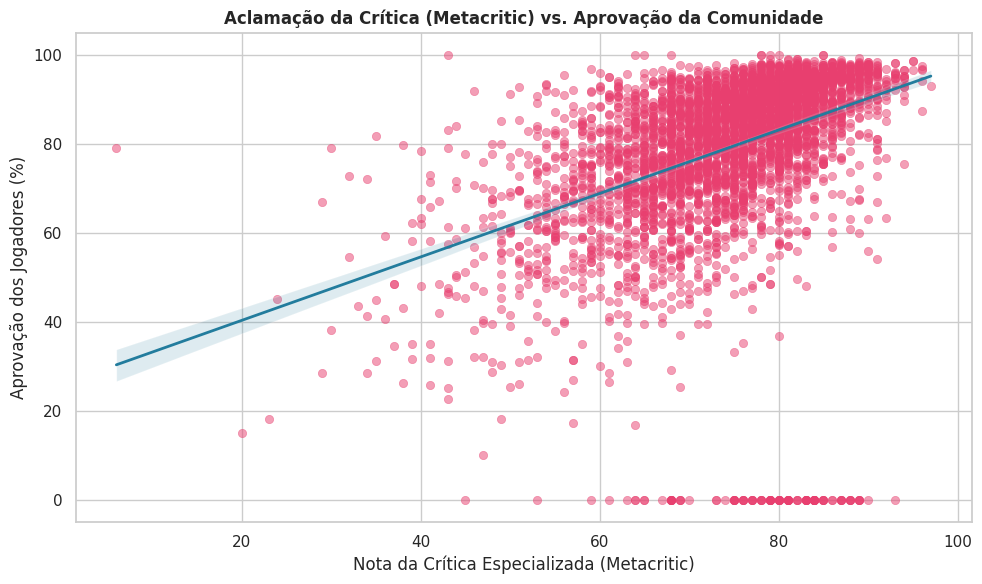

In [ ]:
# MÓDULO 5: CRÍTICA VS. COMUNIDADE

print("Gerando análises do Módulo 5...")

# Filtrar apenas jogos que foram avaliados pelo Metacritic (nota > 0)
df_critica = df_clean[df_clean['Metacritic score'] > 0].copy()

plt.figure(figsize=(10, 6))

# Gráfico de Dispersão para ver onde cada jogo cai no cruzamento de notas
sns.scatterplot(
    data=df_critica, 
    x='Metacritic score', 
    y='Approval (%)', 
    alpha=0.5, 
    color='#e83f6f',
    edgecolor=None
)

# Adicionando uma linha de regressão linear
sns.regplot(
    data=df_critica, 
    x='Metacritic score', 
    y='Approval (%)', 
    scatter=False, 
    color='#227c9d',
    line_kws={"linewidth": 2}
)

plt.title('Aclamação da Crítica (Metacritic) vs. Aprovação da Comunidade', fontweight='bold')
plt.xlabel('Nota da Crítica Especializada (Metacritic)')
plt.ylabel('Aprovação dos Jogadores (%)')
plt.tight_layout()
plt.show()

Gerando análises do Módulo 6...


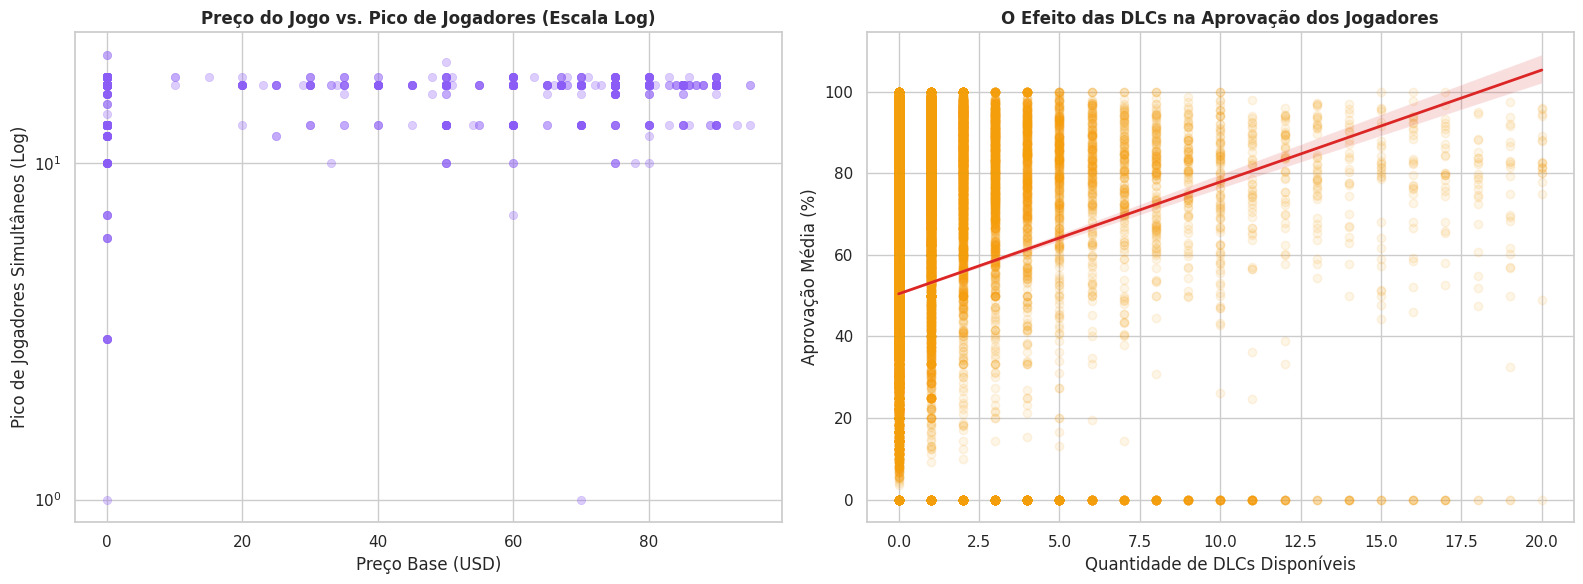

In [ ]:
# MÓDULO 6: MONETIZAÇÃO (PREÇO, DLCs e ENGAJAMENTO)

print("Gerando análises do Módulo 6...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Preço vs. Pico de Jogadores (Usando escala logarítmica)
# Filtrando jogos com pelo menos 1 jogador para não quebrar o log
df_price = df_clean[df_clean['Peak CCU'] > 0].copy()

sns.scatterplot(
    data=df_price, 
    x='Price', 
    y='Peak CCU', 
    alpha=0.3, 
    color='#8b5cf6', 
    edgecolor=None,
    ax=axes[0]
)
axes[0].set_yscale('log') # Escala Logarítmica porque o pico vai de 1 a milhões
axes[0].set_title('Preço do Jogo vs. Pico de Jogadores (Escala Log)', fontweight='bold')
axes[0].set_xlabel('Preço Base (USD)')
axes[0].set_ylabel('Pico de Jogadores Simultâneos (Log)')

# Gráfico 2: Quantidade de DLCs vs. Aprovação da Comunidade
# Jogos com até 20 DLCs para não distorcer o gráfico com os simuladores de trem de 1000 DLCs, por exemplo
df_dlc = df_clean[df_clean['DiscountDLC count'] <= 20].copy()

sns.regplot(
    data=df_dlc, 
    x='DiscountDLC count', 
    y='Approval (%)', 
    scatter_kws={'alpha': 0.1, 'color': '#f59e0b'}, 
    line_kws={'color': '#dc2626', 'linewidth': 2}, 
    ax=axes[1]
)
axes[1].set_title('O Efeito das DLCs na Aprovação dos Jogadores', fontweight='bold')
axes[1].set_xlabel('Quantidade de DLCs Disponíveis')
axes[1].set_ylabel('Aprovação Média (%)')

plt.tight_layout()
plt.show()

Rodando o modelo DBSCAN do Módulo 7...


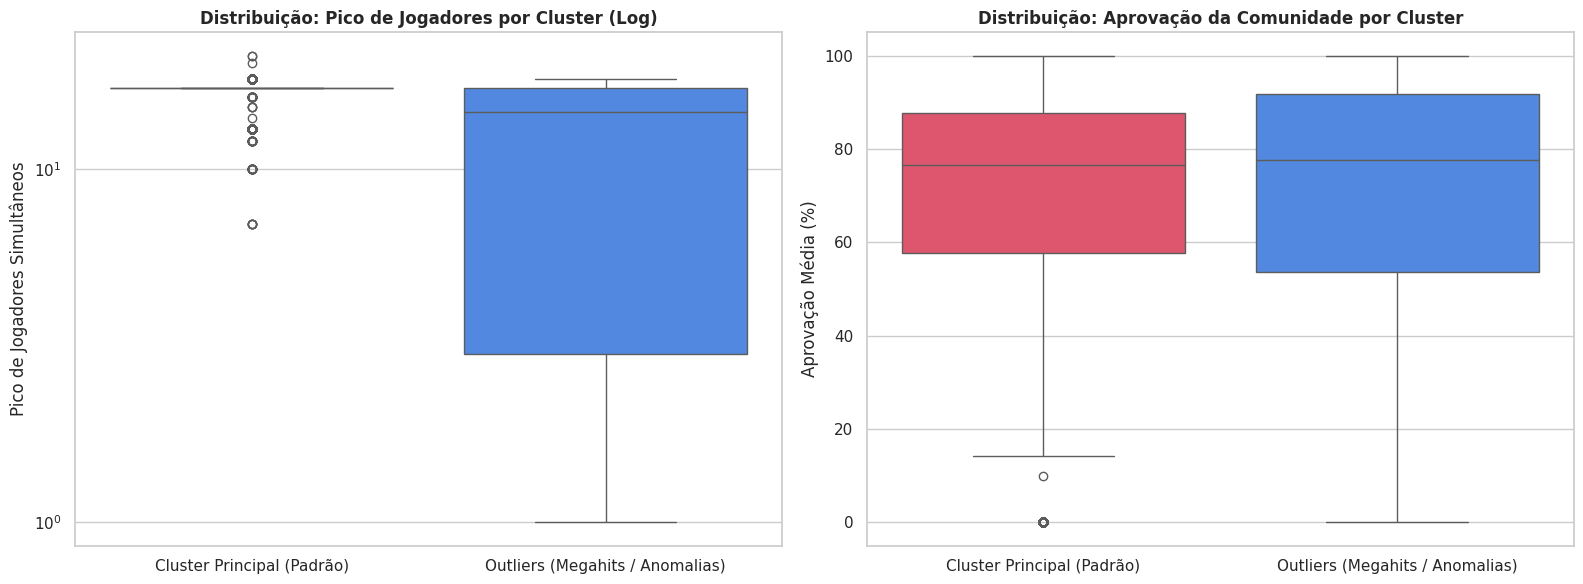

In [ ]:
# MÓDULO 7: MACHINE LEARNING (CLUSTERING COM DBSCAN)

print("Rodando o modelo DBSCAN do Módulo 7...")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Selecionar as métricas cruciais
features = ['Num Languages', 'Approval (%)', 'Total Reviews', 'Peak CCU']
df_ml = df_clean.dropna(subset=features).copy()

# Filtrar jogos com pico > 0 para analisar apenas jogos que realmente foram abertos
df_ml = df_ml[df_ml['Peak CCU'] > 0]

# Normalizar (Para o DBSCAN calcular as distâncias matemáticas corretamente)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml[features])

# Aplicar o modelo de Machine Learning
dbscan = DBSCAN(eps=1.5, min_samples=10)
df_ml['Cluster'] = dbscan.fit_predict(X_scaled)

# O DBSCAN rotula como -1 tudo aquilo que é muito fora da curva (Outliers/Megahits)
df_ml['Categoria'] = df_ml['Cluster'].apply(
    lambda x: 'Outliers (Megahits / Anomalias)' if x == -1 else 'Cluster Principal (Padrão)'
)

# Plotando os Boxplots para escancarar a diferença
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot 1: Alcance (Pico de Jogadores) em Escala Logarítmica
sns.boxplot(data=df_ml, x='Categoria', y='Peak CCU', palette=['#f43f5e', '#3b82f6'], ax=axes[0], hue='Categoria', legend=False)
axes[0].set_yscale('log')
axes[0].set_title('Distribuição: Pico de Jogadores por Cluster (Log)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Pico de Jogadores Simultâneos')

# Boxplot 2: Recepção (Aprovação Média)
sns.boxplot(data=df_ml, x='Categoria', y='Approval (%)', palette=['#f43f5e', '#3b82f6'], ax=axes[1], hue='Categoria', legend=False)
axes[1].set_title('Distribuição: Aprovação da Comunidade por Cluster', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Aprovação Média (%)')

plt.tight_layout()
plt.show()